/Users/seominjae/anaconda3/envs/midterm/bin/python


In [23]:
import numpy

from dataset import raf

dataset = raf('../data/AffectNet7',train=True)

In [24]:
from collections import Counter

In [25]:
count = Counter(dataset.label)

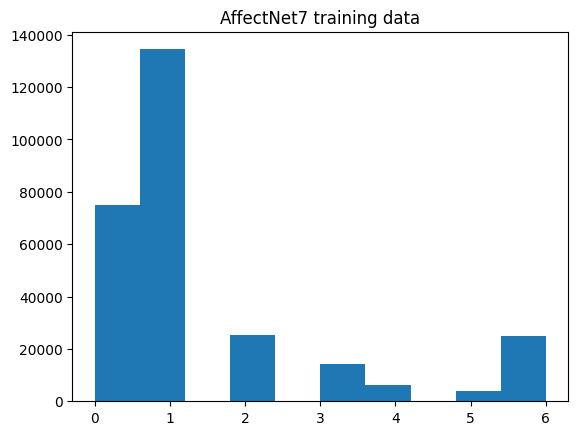

In [26]:
import matplotlib.pyplot as plt 


plt.hist(dataset.label)
plt.title('AffectNet7 training data')
plt.savefig('affect7training.png')

In [9]:
array = []
for key, value in count.items():
    array.append((key,value))
    
array.sort(key=lambda x : x[1])

In [19]:
import numpy as np 
import torch 
array = torch.tensor(array).float()

/var/folders/6m/cd238lz51qs7qkmr_b1h6x600000gn/T/ipykernel_17042/1668562300.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  array = torch.tensor(array).float()


In [53]:
from torch.nn.functional import softmax
def get_adapt(array):
    x = -array[:,1]/sum(array[:,1])
    x = softmax(x,dim=0)
    return torch.concat((array[:,0],x),dim=-1).reshape(2,-1).transpose(-1,-2)

def map_adapt(label,array):
    return array[label,1]

In [54]:
mapp = get_adapt(array)

In [58]:
result = map_adapt(torch.randint(0,7,(3,)),mapp)

In [59]:
result

tensor([0.1015, 0.1252, 0.1015])

In [1]:
from utils.eval_quality import *

/Users/seominjae/anaconda3/envs/midterm/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
from glob import glob 

result = []
for i in range(7):
    paths = glob(f'../data/AffectNet7/train/{i}/*')
    ml = by_ml(paths)
    blur = detect_blur(paths)
    result.append((i,blur,ml))

In [3]:
result

[(0, 230.42333551899046, 25.00421482094353),
 (1, 233.55548057866264, 23.326390043037158),
 (2, 205.93554768306444, 27.146524851948627),
 (3, 221.5771996582617, 25.91449493175003),
 (4, 211.0776340614912, 27.751839473460414),
 (5, 202.0234107708438, 26.404232898359233),
 (6, 237.73016039540747, 25.264443894472695)]

In [9]:
from dataset import exc_label
fixed = []
for orig_label, blur, ml in result:
    fixed.append((exc_label(orig_label),blur,ml))

In [12]:
import numpy as np 
array = np.array(fixed)
array[:,1] = array[:,1]/array[:,1].sum()
array[:,2] = array[:,2]/array[:,2].sum()
print(array)

[[6.         0.1494002  0.13828836]
 [3.         0.151431   0.12900898]
 [4.         0.13352299 0.15013663]
 [0.         0.14366461 0.14332276]
 [1.         0.13685698 0.15348438]
 [2.         0.13098647 0.14603131]
 [5.         0.15413775 0.13972759]]


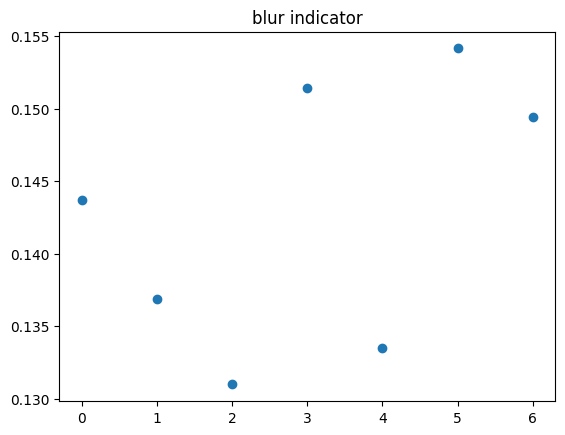

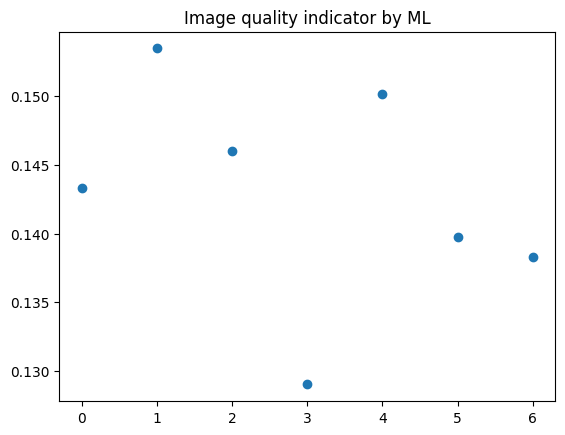

In [14]:
import matplotlib.pyplot as plt
plt.scatter(array[:,0],array[:,1],label='blur')
plt.title('blur indicator')
plt.show()
plt.scatter(array[:,0],array[:,2],label='ml')
plt.title('Image quality indicator by ML')
plt.show()

In [7]:
[i for i in range(50//3,50,50//3)]

[16, 32, 48]

In [1]:
from torch import nn
a = nn.Linear(512,7)

/Users/seominjae/anaconda3/envs/midterm/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [4]:
w = a.weight

In [5]:
w.shape

torch.Size([7, 512])

In [6]:
w = w/w.norm(p=2,dim=-1,keepdim=True)

In [8]:
w[0].norm()

tensor(1., grad_fn=<LinalgVectorNormBackward0>)

In [1]:
from dataset import FER
from argparse import Namespace
args = {'data_path':'../data/AffectNet7','world_size':1,'rank':0,}
args = Namespace(**args)
dataset = FER(args,'./checkpoint/quality')

/Users/seominjae/anaconda3/envs/midterm/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
/Users/seominjae/rl/dataset/__init__.py:113: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  class_qualities = nn.functional.softmax(-class_qualities)


In [2]:
dataset.class_qualities

tensor([0.1413, 0.1234, 0.1363, 0.1708, 0.1290, 0.1482, 0.1510])

In [2]:
from collections import defaultdict

In [7]:
k = defaultdict(int)
k[1]=3
k[0]=2

[1, 0]

In [9]:
k

defaultdict(int, {1: 3, 0: 2})

In [3]:
import torch 

x = torch.arange(7)

rot = [torch.roll(x,shifts=i) for i in range(1,len(x))]
rot = torch.stack(rot)
print(rot)

tensor([[6, 0, 1, 2, 3, 4, 5],
        [5, 6, 0, 1, 2, 3, 4],
        [4, 5, 6, 0, 1, 2, 3],
        [3, 4, 5, 6, 0, 1, 2],
        [2, 3, 4, 5, 6, 0, 1],
        [1, 2, 3, 4, 5, 6, 0]])


In [6]:
x - rot

tensor([[-6,  1,  1,  1,  1,  1,  1],
        [-5, -5,  2,  2,  2,  2,  2],
        [-4, -4, -4,  3,  3,  3,  3],
        [-3, -3, -3, -3,  4,  4,  4],
        [-2, -2, -2, -2, -2,  5,  5],
        [-1, -1, -1, -1, -1, -1,  6]])

In [7]:
x

tensor([0, 1, 2, 3, 4, 5, 6])

In [8]:
rot.shape

torch.Size([6, 7])

In [10]:
torch.min(torch.abs(x-rot),dim=0)

torch.return_types.min(
values=tensor([1, 1, 1, 1, 1, 1, 1]),
indices=tensor([5, 0, 0, 0, 0, 0, 0]))

In [17]:
x = torch.arange(9)

In [18]:
x = x.reshape(3,3)

In [21]:
indice = [1,0,2]

In [25]:
x[torch.arange(3),indice]

tensor([1, 3, 8])

In [26]:
x

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [27]:
x = torch.randn((512,15000))
x = x.transpose(-1,-2)@x

In [30]:
_, indice = torch.max(x,dim=-1)

In [33]:
indice.shape

torch.Size([15000])

In [1]:
from dataset import FER 
from argparse import Namespace

args = {'data_path':'../data/AffectNet7',
        'world_size':1}
args = Namespace(**args)
dataset = FER(args,'checkpoint/quality',train=True)

/Users/seominjae/anaconda3/envs/midterm/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
/Users/seominjae/rl/dataset/__init__.py:116: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  class_qualities = nn.functional.softmax(-class_qualities)


In [2]:
from Loss import Proportion_loss
import torch 
pl = Proportion_loss(dataset.labels,alpha=0,device=torch.device('cpu'))

/Users/seominjae/rl/Loss/__init__.py:20: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = torch.nn.functional.softmax(x)


In [3]:
pl.array

[(0, 14090),
 (1, 6378),
 (2, 3803),
 (3, 134415),
 (4, 25459),
 (5, 24882),
 (6, 74874)]

(array([ 14090.,   6378.,      0.,   3803.,      0., 134415.,  25459.,
             0.,  24882.,  74874.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

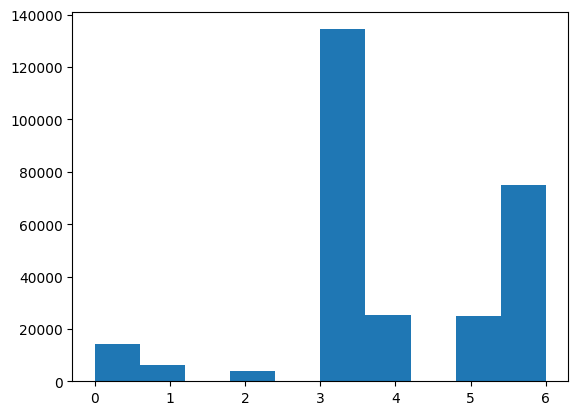

In [4]:
from matplotlib import pyplot as plt 
import numpy
pl.array = numpy.array(pl.array)
plt.hist(dataset.labels)

In [5]:
print(pl.proportion_weights)

tensor([1.5396, 1.5466, 1.5487, 1.0000, 1.5269, 1.5276, 1.4182])


In [54]:
dataset.class_qualities

tensor([0.1413, 0.1234, 0.1363, 0.1708, 0.1290, 0.1482, 0.1510])

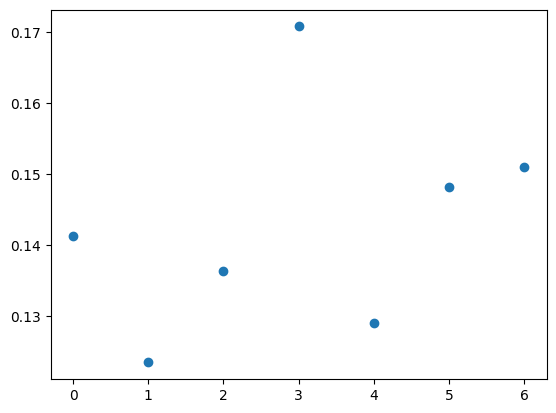

In [8]:
plt.scatter(torch.arange(7),dataset.class_qualities)

In [9]:
label = torch.arange(7)
print(pl.get_gamma(label))

tensor([0.0918, 0.1119, 0.1273, 0.0522, 0.0792, 0.0796, 0.0605])


In [49]:
pl.proportion

tensor([ 14090.,   6378.,   3803., 134415.,  25459.,  24882.,  74874.])

/Users/seominjae/anaconda3/envs/midterm/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


TypeError: FER.__init__() missing 1 required positional argument: 'ckpt_path'